# EDA - Consumer Reviews of Amazon Products

## 1. Import Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_csv(
    "RAW/1429_1.csv",
    low_memory=False
)


## 2. Dataset Overview

In [2]:
display(df.head())

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [3]:
print(df.shape)

(34660, 21)


In [4]:
print(df.columns.tolist())


['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [6]:

df.describe(include="all")

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
count,34660,27900,34658,34660,34660,34660,34660,34621,24039,34660,...,34066,1.0,34131.000000,34627.000000,34660,34659,34654,0.0,0.0,34653
unique,42,48,41,6,41,42,2,1078,1941,3911,...,2,NaN,NaN,NaN,11929,34659,19766,NaN,NaN,26788
top,AVphgVaX1cnluZ0-DR74,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",B018Y229OU,Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",firetablet7displaywifi8gbincludesspecialoffers...,Amazon,2017-01-16T00:00:00.000Z,2017-09-05T22:09:30Z,"2017-09-28T00:00:00Z,2017-09-08T00:00:00Z,2017...",...,True,NaN,NaN,NaN,https://www.amazon.com/product-reviews/B01J2G4...,to spite the fact that i have nothing but good...,Great product,NaN,NaN,Mike
freq,10966,10966,10966,28701,10966,10966,34639,710,3127,5072,...,32682,NaN,NaN,NaN,387,1,645,NaN,NaN,138
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.630248,4.584573,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.215775,0.735653,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data quality

### 3.1 Missing values

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "%": missing_pct})

,missing,%
reviews.userCity,34660,100.00
reviews.userProvince,34660,100.00
reviews.id,34659,100.00
reviews.didPurchase,34659,100.00
reviews.dateAdded,10621,30.64
name,6760,19.50
reviews.doRecommend,594,1.71
reviews.numHelpful,529,1.53
reviews.date,39,0.11
reviews.rating,33,0.10


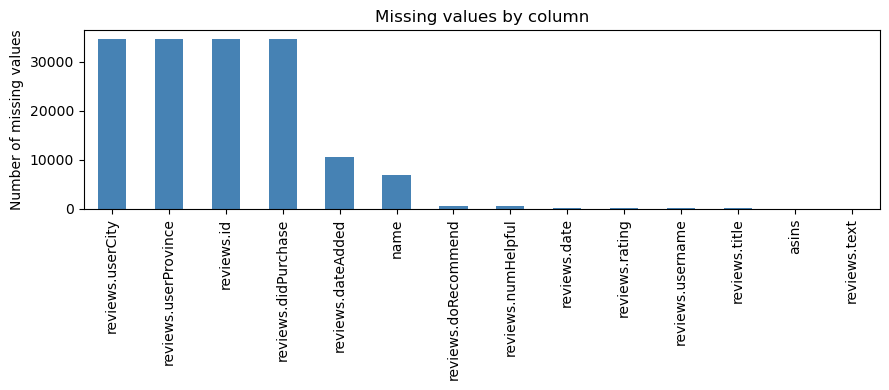

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
missing[missing > 0].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Missing values by column")
ax.set_ylabel("Number of missing values")
plt.tight_layout(); plt.show()

In [9]:
# Nearly empty columns (>99% missing) -> candidates for removal
empty_cols = missing_pct[missing_pct > 99].index.tolist()
print("Columns >99% missing:", empty_cols)

# Constant columns (single value) -> carry no information
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("Constant columns:", constant_cols)

Columns >99% missing: ['reviews.userCity', 'reviews.userProvince', 'reviews.id', 'reviews.didPurchase']
Constant columns: ['reviews.didPurchase', 'reviews.id', 'reviews.userCity', 'reviews.userProvince']


### 3.2  Duplicate Analysis

In [10]:
df.duplicated().sum()

0

In [11]:
df["reviews.text"].duplicated().sum()

0

## 4. Target Variable Exploration (Ratings)

Rating -> sentiment mapping: **1-2 = Negative · 3 = Neutral · 4-5 = Positive**

In [12]:
df["reviews.rating"].value_counts().sort_index()

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23775
Name: count, dtype: int64

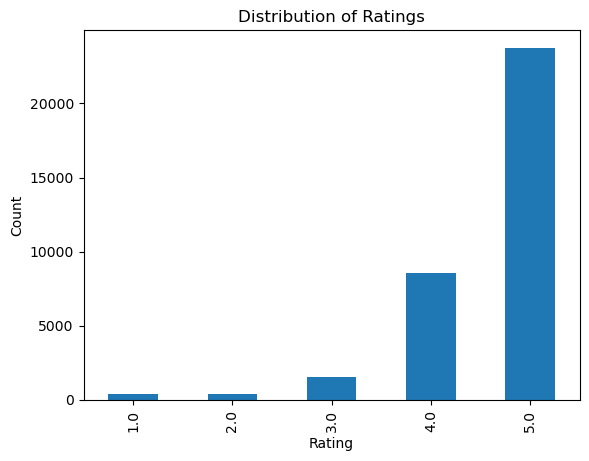

In [13]:
df["reviews.rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [14]:
def map_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

# Create target variable
df["sentiment"] = df["reviews.rating"].apply(map_sentiment)


assert df["sentiment"].notna().all(), "Missing sentiment labels"

dist = df["sentiment"].value_counts()
pd.DataFrame({"n": dist, "%": (dist / len(df) * 100).round(2)})

,n,%
sentiment,,
Positive,32349,93.33
Neutral,1499,4.32
Negative,812,2.34


In [15]:
ratio = dist.max() / dist.min()
print(f"Imbalance ratio (majority / minority): {ratio:.1f} : 1")
print(f"Negative class: {dist['Negative']} reviews ({dist['Negative']/len(df)*100:.2f}% of total)")

Imbalance ratio (majority / minority): 39.8 : 1
Negative class: 812 reviews (2.34% of total)


## 5. Categories

In [16]:
df["categories"].value_counts().head(15)

categories
Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               10966
Stereos,Remote Controls,Amazon Echo,Audio Docks & Mini Speakers,Amazon Echo Accessories,Kitchen & Dining Features,Speaker Systems,Electronics,TVs Entertainment,Clearance,Smart Hubs & Wireless Routers,Featured Brands,Wireless Speakers,Smart Home & Connect

### 5.1 Brands

In [17]:
df["brand"].value_counts().head(15)

brand
Amazon                          28701
Amazon Fire Tv                   5056
Amazon Echo                       636
Amazon Fire                       256
Amazon Digital Services Inc.       10
Amazon Coco T                       1
Name: count, dtype: int64

## 6. Text Review 

### 6.1 Length

In [18]:
df["review_length"] = df["reviews.text"].str.len()

In [19]:
df["review_length"].describe()

count    34659.000000
mean       159.047434
std        185.837884
min          3.000000
25%         70.000000
50%        106.000000
75%        183.000000
max      10670.000000
Name: review_length, dtype: float64

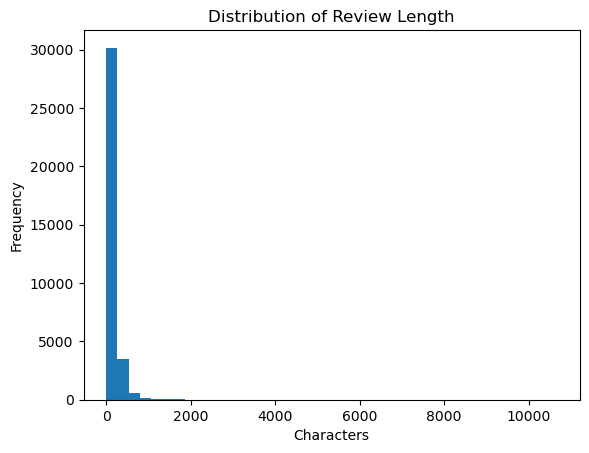

In [20]:
plt.hist(df["review_length"], bins=40)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")
plt.show()

### 6.2 Word Count

In [21]:
df["char_count"] = df["reviews.text"].str.len()
df["word_count"] = df["reviews.text"].str.split().str.len()

df[["char_count", "word_count"]].describe().round(1)

,char_count,word_count
count,34659.0,34659.0
mean,159.0,30.4
std,185.8,34.6
min,3.0,1.0
25%,70.0,13.0
50%,106.0,21.0
75%,183.0,35.0
max,10670.0,1858.0


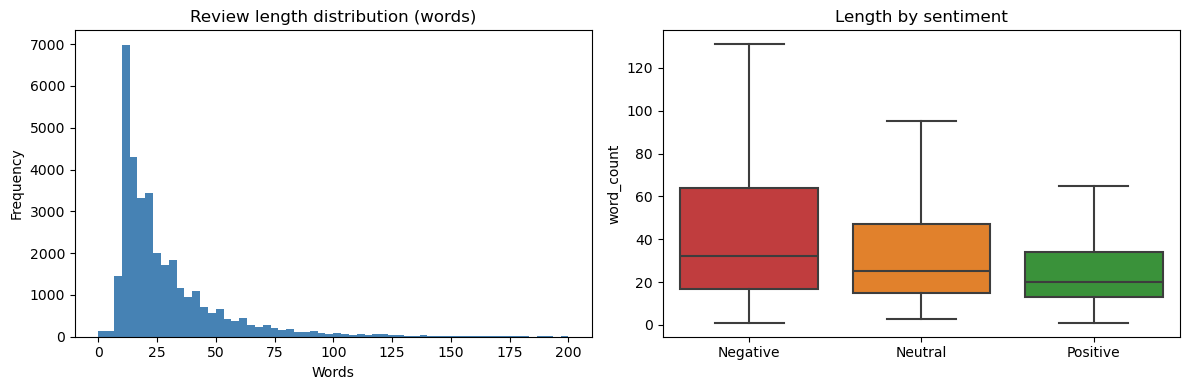

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["word_count"], bins=60, range=(0, 200), color="steelblue")
axes[0].set_title("Review length distribution (words)")
axes[0].set_xlabel("Words"); axes[0].set_ylabel("Frequency")

order = ["Negative", "Neutral", "Positive"]
sns.boxplot(data=df, x="sentiment", y="word_count", order=order,
            ax=axes[1], showfliers=False,
            palette=["#d62728", "#ff7f0e", "#2ca02c"])
axes[1].set_title("Length by sentiment"); axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

##### Most Frequent Words

In [23]:
words = " ".join(
    df["reviews.text"].dropna()
).lower().split()

In [24]:
from collections import Counter
from nltk.corpus import stopwords
import nltk
import re

# Download stopwords (only needed the first time)
nltk.download("stopwords")

# English stopwords
stop_words = set(stopwords.words("english"))

# Join all review text (without modifying the dataframe)
text = " ".join(df["reviews.text"].dropna()).lower()

# Remove punctuation and numbers
text = re.sub(r"[^a-z\s]", "", text)

# Tokenize and remove stopwords
words = [
    word for word in text.split()
    if word not in stop_words
]

# Display the 30 most common words
common_words = Counter(words).most_common(30)

pd.DataFrame(common_words, columns=["Word", "Frequency"])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/felipemartignon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Word,Frequency
0,great,11737
1,tablet,8963
2,use,7605
3,love,6590
4,easy,6140
5,amazon,5687
6,kindle,5332
7,bought,5048
8,good,4999
9,one,4959


####  Sentiment Distribution

In [25]:
print(df["reviews.rating"].value_counts(dropna=False).sort_index())
print(df["sentiment"].value_counts())

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23775
NaN       33
Name: count, dtype: int64
sentiment
Positive    32349
Neutral      1499
Negative      812
Name: count, dtype: int64


<Axes: xlabel='sentiment'>

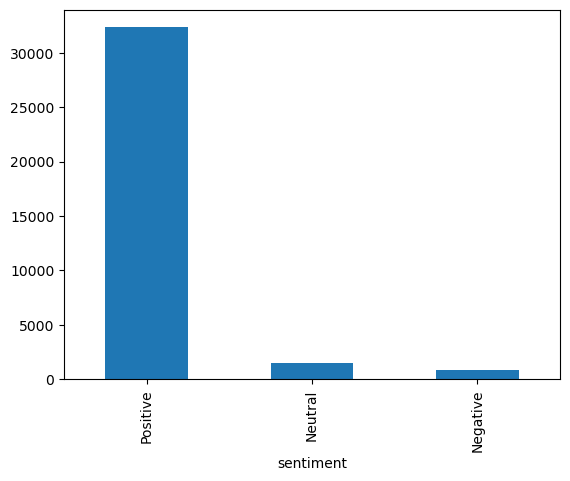

In [26]:
df["sentiment"].value_counts().plot(kind="bar")

#### Review Length vs Rating

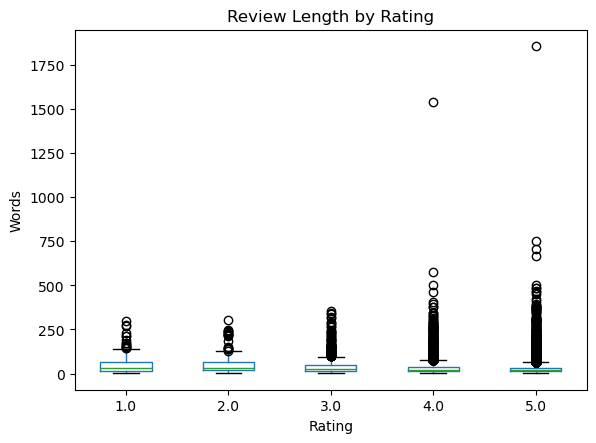

In [27]:
import matplotlib.pyplot as plt

df.boxplot(column="word_count", by="reviews.rating", grid=False)
plt.title("Review Length by Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Words")
plt.show()

#### Top Products

In [28]:
df["name"].value_counts().head(10)

name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                                                           10966
Echo (White),,,\r\nEcho (White),,,                                                                                                                3309
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,                                         3176
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                                                           2814
Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,                                                                                                            2527
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case                                                                           1685
Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,                

#### Top Brands

In [29]:
df.groupby("brand")["reviews.rating"].mean().sort_values(ascending=False)

brand
Amazon Fire Tv                  4.707278
Amazon                          4.564721
Amazon Fire                     4.558594
Amazon Echo                     4.531447
Amazon Digital Services Inc.    3.500000
Amazon Coco T                        NaN
Name: reviews.rating, dtype: float64

#### Correlation

In [30]:
df[["reviews.rating","reviews.numHelpful","word_count"]].corr()

,reviews.rating,reviews.numHelpful,word_count
reviews.rating,1.000000,-0.042395,-0.109763
reviews.numHelpful,-0.042395,1.000000,0.218580
word_count,-0.109763,0.218580,1.000000


## Data Cleaning Before Splitting

#### Dropping Columns

In [31]:
columns_to_keep = [
    "name",
    "brand",
    "categories",
    "reviews.rating",
    "reviews.text",
    "reviews.title",
    "reviews.numHelpful",
    "reviews.doRecommend",
    "sentiment",
    "id",
    "keys",
    "asins"
]

df = df[columns_to_keep].copy()

In [32]:
df.isnull().sum()

name                   6760
brand                     0
categories                0
reviews.rating           33
reviews.text              1
reviews.title             6
reviews.numHelpful      529
reviews.doRecommend     594
sentiment                 0
id                        0
keys                      0
asins                     2
dtype: int64

#### Handling Missing Values

In [33]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

name                   6760
reviews.doRecommend     594
reviews.numHelpful      529
reviews.rating           33
reviews.title             6
asins                     2
reviews.text              1
brand                     0
categories                0
sentiment                 0
id                        0
keys                      0
dtype: int64


In [34]:
df[["name", "brand", "categories"]].isnull().sum()

name          6760
brand            0
categories       0
dtype: int64

In [35]:
df[df["name"].isna()]

,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment,id,keys,asins
27900,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",4.0,Doesn't always do what I asked for. It is prob...,Nice to not have to use a switch somewhere.,0.0,True,Positive,AVpfl8cLLJeJML43AE3S,"echowhite/263039693056,echowhite/152558276095,...","B00L9EPT8O,B01E6AO69U"
27901,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,I absolutely love this devise. I do wish ti wa...,It is all that it is advertised to be!,0.0,True,Positive,AVpfl8cLLJeJML43AE3S,"echowhite/263039693056,echowhite/152558276095,...","B00L9EPT8O,B01E6AO69U"
27902,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,Absolutely love this thing! It controls my lig...,Couldn't be happier,0.0,True,Positive,AVpfl8cLLJeJML43AE3S,"echowhite/263039693056,echowhite/152558276095,...","B00L9EPT8O,B01E6AO69U"
27903,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,I bought this echo when it was first released ...,Make sure your home is equipped.,0.0,True,Positive,AVpfl8cLLJeJML43AE3S,"echowhite/263039693056,echowhite/152558276095,...","B00L9EPT8O,B01E6AO69U"
27904,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,The Amazon Echo is super easy to set up. Once ...,Easy to use and very helpful,0.0,True,Positive,AVpfl8cLLJeJML43AE3S,"echowhite/263039693056,echowhite/152558276095,...","B00L9EPT8O,B01E6AO69U"
...,...,...,...,...,...,...,...,...,...,...,...,...
34655,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",3.0,This is not appreciably faster than any other ...,Not appreciably faster than any other 1.8A cha...,NaN,NaN,Neutral,AVpfiBlyLJeJML43-4Tp,newamazonkindlefirehd9wpowerfastadaptercharger...,B006GWO5WK
34656,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",1.0,Amazon should include this charger with the Ki...,Should be included,NaN,NaN,Negative,AVpfiBlyLJeJML43-4Tp,newamazonkindlefirehd9wpowerfastadaptercharger...,B006GWO5WK
34657,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",1.0,Love my Kindle Fire but I am really disappoint...,Disappointing Charger,NaN,NaN,Negative,AVpfiBlyLJeJML43-4Tp,newamazonkindlefirehd9wpowerfastadaptercharger...,B006GWO5WK
34658,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",1.0,I was surprised to find it did not come with a...,Not worth the money,NaN,NaN,Negative,AVpfiBlyLJeJML43-4Tp,newamazonkindlefirehd9wpowerfastadaptercharger...,B006GWO5WK


In [36]:
df[df["name"].isna()][
    ["brand", "categories", "reviews.text", "reviews.rating"]
].head(10)

,brand,categories,reviews.text,reviews.rating
27900,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",Doesn't always do what I asked for. It is prob...,4.0
27901,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",I absolutely love this devise. I do wish ti wa...,5.0
27902,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",Absolutely love this thing! It controls my lig...,5.0
27903,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",I bought this echo when it was first released ...,5.0
27904,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",The Amazon Echo is super easy to set up. Once ...,5.0
27905,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","My family and i love it,its now a member of ou...",5.0
27906,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","I was very skeptical at first with this, but A...",5.0
27907,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","From news, to music, to the weather and much m...",5.0
27908,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",I love just being able to wake up in the morni...,5.0
27909,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Originally figured this would be almost a toy,...",5.0


#### Removing rows without review text and rating

In [37]:
df = df.dropna(subset=["reviews.text"])

In [38]:
df = df.dropna(subset=["reviews.rating"])

In [39]:
# Validate cleaned target
assert df["sentiment"].notna().all(), "Missing sentiment labels after cleaning"

print("✅ All remaining reviews have a valid sentiment label.")

✅ All remaining reviews have a valid sentiment label.


## 9. What we keep and what we drop — and why

### Dropped (removed from the dataset)

| Column | Reason |
|---|---|
| `reviews.userCity`, `reviews.userProvince` | 100% missing values; no usable information. |
| `reviews.id`, `reviews.didPurchase` | More than 99.9% missing values; insufficient data for analysis. |
| `reviews.date`, `reviews.dateAdded`, `reviews.dateSeen` | Temporal metadata not required for the objectives of this project. |
| `id`, `asins`, `keys` | Product identifiers with no predictive value for NLP tasks. |
| `manufacturer` | Near-constant feature (almost all values are `"Amazon"`), providing little analytical value. |
| `reviews.sourceURLs` | URLs containing no useful information for text analysis. |
| `reviews.username` | High-cardinality identifier with no predictive value. |

### Kept in the cleaned dataset

| Column | Purpose |
|---|---|
| `name` | Product name used for product-level analysis, clustering interpretation, and generative summaries. |
| `brand` | Product metadata used for segmentation and business insights. |
| `categories` | Product metadata used to interpret and validate clustering results. |
| `reviews.rating` | Original customer rating retained for traceability and business analysis. |
| `reviews.text` | Main textual input for all NLP tasks. |
| `reviews.title` | Additional textual context that can be combined with the review body in the classification and generative models. |
| `reviews.numHelpful` | Useful descriptive metadata for EDA and future analyses. |
| `reviews.doRecommend` | Retained for business analysis but excluded from predictive models. |
| `sentiment` | Target variable created from the review rating (1–2 = Negative, 3 = Neutral, 4–5 = Positive). |

### Excluded from the Classification Model

| Column | Reason |
|---|---|
| `reviews.rating` | Used to derive the target variable (`sentiment`). Including it as a feature would introduce target leakage. |
| `reviews.doRecommend` | Strongly correlated with customer sentiment and not available when predicting sentiment from raw review text. Including it would artificially inflate model performance. |
| `reviews.numHelpful` | Represents feedback received after the review was published and would not be available at prediction time. |

### Model Variables

- **Input (`X`)**: `reviews.title` + `reviews.text`
- **Target (`y`)**: `sentiment`

> **Note:** The original `reviews.rating` column is retained in the cleaned dataset for traceability and business analysis, but it is **never used as an input feature**, since it is the source from which the target variable is derived.

#### Final dataset

In [40]:
print("Final dataset shape:", df.shape)

display(df.head())

df.info()

Final dataset shape: (34626, 12)


,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment,id,keys,asins
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2


<class 'pandas.core.frame.DataFrame'>
Index: 34626 entries, 0 to 34659
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 27867 non-null  object 
 1   brand                34626 non-null  object 
 2   categories           34626 non-null  object 
 3   reviews.rating       34626 non-null  float64
 4   reviews.text         34626 non-null  object 
 5   reviews.title        34620 non-null  object 
 6   reviews.numHelpful   34131 non-null  float64
 7   reviews.doRecommend  34066 non-null  object 
 8   sentiment            34626 non-null  object 
 9   id                   34626 non-null  object 
 10  keys                 34626 non-null  object 
 11  asins                34624 non-null  object 
dtypes: float64(2), object(10)
memory usage: 3.4+ MB


##  Save clean data 

In [41]:
import os

# Create processed folder if it doesn't exist
os.makedirs("processed", exist_ok=True)

# Save cleaned dataset
df.to_csv(
    "processed/amazon_reviews_clean.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [42]:
import os

os.listdir("processed")

['amazon_reviews_clean.csv']

## Cleaning Summary

- Original dataset: **34,660** reviews
- Final dataset: **34,626** reviews
- Removed:
  - 33 reviews without ratings
  - 1 review without review text
- Final features: **9**

The cleaned dataset is now ready for:
- Sentiment Classification
- Product Category Clustering
- Generative AI Summarization